### Leave One Out Cross Validation

In [4]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut, cross_val_score

# Load the Boston Housing dataset
df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv')
X = df.iloc[:,0:-1]
y = df.iloc[:,-1]

# Create a linear regression model
model = LinearRegression()

# Create a LeaveOneOut cross-validator
loo = LeaveOneOut()

# Use cross_val_score for the dataset with the model and LOOCV
# This will return the scores for each iteration of LOOCV
scores = cross_val_score(model, X, y, cv=loo, scoring='neg_mean_squared_error')

mse_scores = -scores  # Invert the sign of the scores

# Print the mean MSE over all LOOCV iterations
print("Mean MSE:", mse_scores.mean())

Mean MSE: 23.725745519476195


### K Fold Cross Validation

In [1]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
import pandas as pd

# Load the Boston Housing dataset
df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv')
X = df.iloc[:,0:-1]
y = df.iloc[:,-1]

# Initialize a Linear Regression model
model = LinearRegression()

# Initialize the KFold parameters
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

# Use cross_val_score on the model and dataset
scores = cross_val_score(model, X, y, cv=kfold, scoring='r2')

print("R2 scores for each fold:", scores)
print("Mean R2 score across all folds:", scores.mean())


R2 scores for each fold: [0.75981355 0.60908125 0.76975858 0.71639463 0.61663293 0.79789535
 0.76682601 0.79453027 0.74066667 0.59908146]
Mean R2 score across all folds: 0.717068071487146


C:\Users\user\AppData\Local\Temp\ipykernel_12372\3586673323.py:12: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  auto_mpg = pd.read_csv(url, names=column_names, delim_whitespace=True, na_values='?')


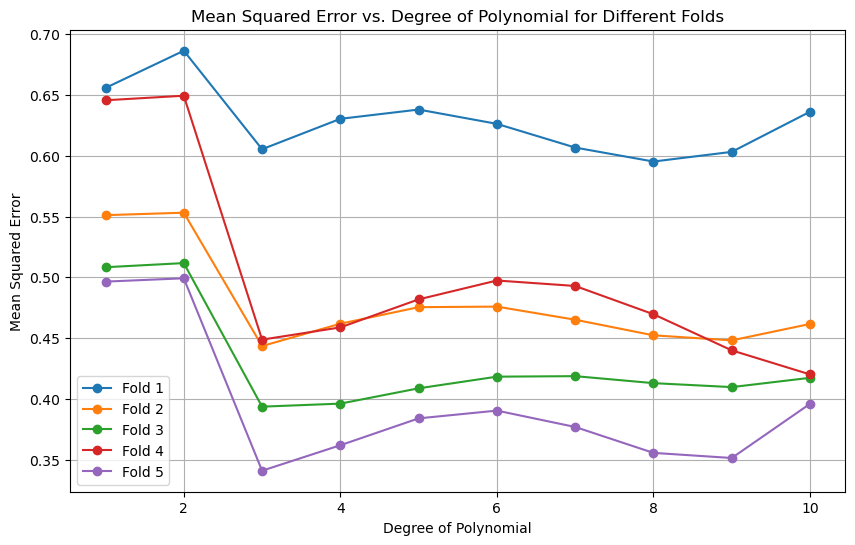

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

# Load the Auto MPG dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight', 'Acceleration', 'Model Year', 'Origin']
auto_mpg = pd.read_csv(url, names=column_names, delim_whitespace=True, na_values='?')

# Drop rows with missing values
auto_mpg = auto_mpg.dropna()

# Define features and target
features = auto_mpg[['Horsepower']]  # Only use 'Horsepower' as a feature
target = auto_mpg['MPG']

# Convert to numpy arrays for easier manipulation
X = features.to_numpy()
y = target.to_numpy()

# List of polynomial degrees
degrees = list(range(1, 11))  # Extend degrees to 10

# Create a plot
plt.figure(figsize=(10, 6))

# Create a 10-fold cross validator
kf = KFold(n_splits=5, shuffle=True, random_state=1)

for i, (train_index, test_index) in enumerate(kf.split(X)):
    # Split the data
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # List to store Mean Squared Errors
    mse_list = []

    for degree in degrees:
        # Add polynomial features
        poly = PolynomialFeatures(degree=degree)
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)

        # Create a linear regression model
        model = LinearRegression()

        # Train the model on the polynomial features training data
        model.fit(X_train_poly, y_train)

        # Use the trained model to predict the target values in the test set
        y_pred = model.predict(X_test_poly)

        # Calculate the Mean Squared Error of the model on the test set
        mse = mean_squared_error(y_test, y_pred)

        # Store the Mean Squared Error in the list
        mse_list.append(mse)

    # Plot the Mean Squared Error as a function of the degree of the polynomial for the current fold
    plt.plot(degrees, mse_list, marker='o', label=f'Fold {i + 1}')

plt.title('Mean Squared Error vs. Degree of Polynomial for Different Folds')
plt.xlabel('Degree of Polynomial')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

### Stratified Cross Validation

In [3]:
from sklearn.datasets import load_iris
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression

# Load iris dataset
data = load_iris()
X, y = data.data, data.target

# Create a Logistic Regression model
model = LogisticRegression(max_iter=10000, random_state=42)

# Create StratifiedKFold object
skf = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

# Perform stratified cross validation
scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy')

# Print the accuracy for each fold
print("Accuracies for each fold: ", scores)
print("Mean accuracy across all folds: ", scores.mean())


Accuracies for each fold:  [1.         0.96666667 0.93333333 1.         0.93333333]
Mean accuracy across all folds:  0.9666666666666668
